Medical Insurance Cost 

This project is based on a Medical Insurance Dataset that contains information about 1,338 individuals. The dataset includes details such as age, gender, BMI, number of children, smoking status, and region. Using these details, our goal is to predict the annual medical insurance charges of a person. As the target variable charges is a continuous numerical value, we apply Regression techniques to build our prediction model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\laksh\Downloads\insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(numeric_cols)

['age', 'bmi', 'children', 'charges']


OUTLIER DETECTION

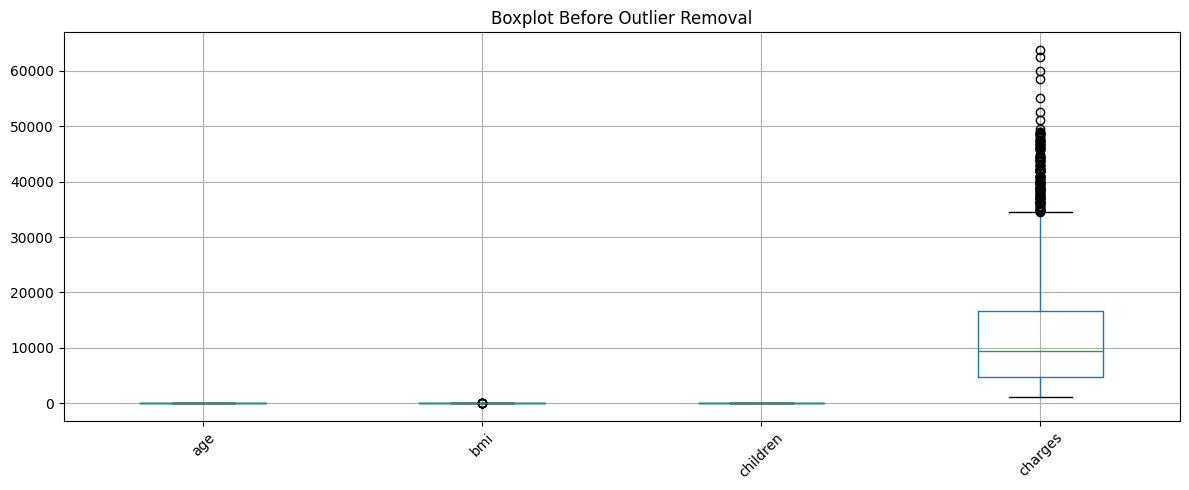

Rounds needed    : 4
Rows after removal: 1105


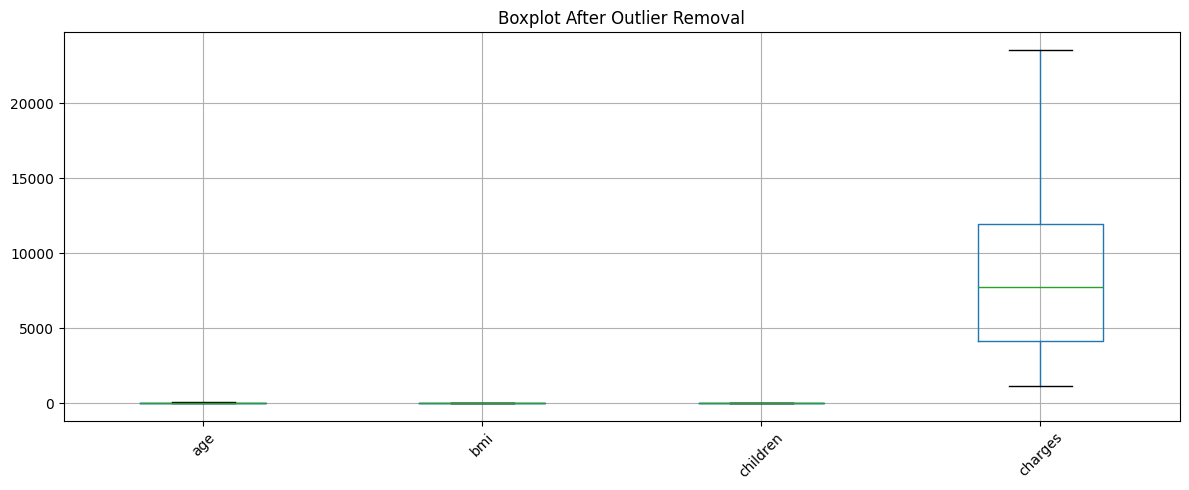

In [9]:
import matplotlib.pyplot as plt

# Define numeric columns
numeric_cols = ['age', 'bmi', 'children', 'charges']

# ── Before Outlier Removal ──────────────────────────────────────
df[numeric_cols].boxplot(figsize=(12, 5))
plt.xticks(rotation=45)
plt.title("Boxplot Before Outlier Removal")
plt.tight_layout()
plt.show()

# ── Remove Outliers Using IQR Loop ─────────────────────────────
rounds = 0
while True:
    total_outliers = set()
    for col in numeric_cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_index = df[
            (df[col] < Q1 - 1.5 * IQR) |
            (df[col] > Q3 + 1.5 * IQR)
        ].index
        total_outliers.update(outlier_index)
    if len(total_outliers) == 0:
        break
    df = df.drop(index=total_outliers).reset_index(drop=True)
    rounds += 1

print("Rounds needed    :", rounds)
print("Rows after removal:", len(df))

# ── After Outlier Removal ───────────────────────────────────────
df[numeric_cols].boxplot(figsize=(12, 5))
plt.xticks(rotation=45)
plt.title("Boxplot After Outlier Removal")
plt.tight_layout()
plt.show()

**EDA**

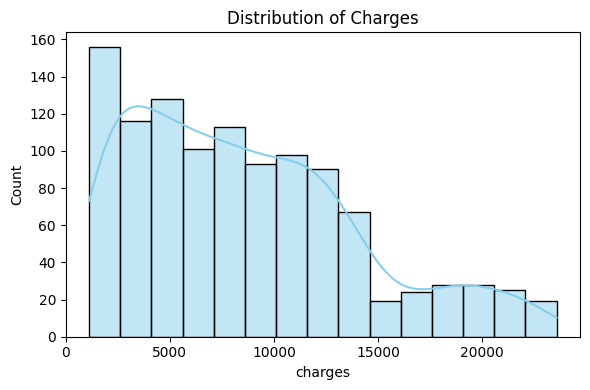

In [10]:
# Distribution of Target Variable (Charges)
plt.figure(figsize=(6, 4))
sns.histplot(df['charges'], kde=True, color='skyblue')
plt.title("Distribution of Charges")
plt.tight_layout()
plt.show()

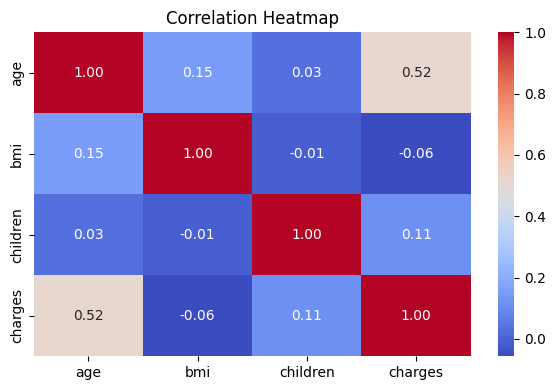

In [11]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['age', 'bmi', 'children', 'charges']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

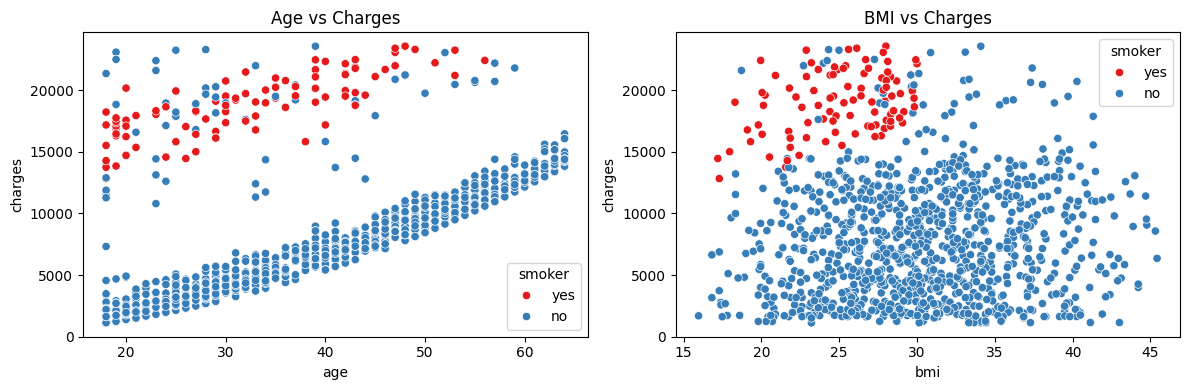

In [12]:
# Age & BMI vs Charges
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[0], palette='Set1')
axes[0].set_title("Age vs Charges")

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[1], palette='Set1')
axes[1].set_title("BMI vs Charges")

plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex']    = le.fit_transform(df['sex'])      
df['smoker'] = le.fit_transform(df['smoker'])   
df['region'] = le.fit_transform(df['region'])   

print("After Encoding:")
print(df.head())

After Encoding:
   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


TRAIN TEST SPLIT

In [14]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['charges'])
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODELS

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("Linear Regression:")
print("  R² Score :", round(r2_score(y_test, lr_pred), 4))
print("  MAE      :", round(mean_absolute_error(y_test, lr_pred), 2))

Linear Regression:
  R² Score : 0.7226
  MAE      : 1471.86


In [23]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scale y too!
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train_scaled, y_train_scaled)

# Predict and inverse transform back to dollars
svr_pred_scaled = svr.predict(X_test_scaled)
svr_pred = scaler_y.inverse_transform(svr_pred_scaled.reshape(-1, 1)).ravel()

print("R² Score:", round(r2_score(y_test, svr_pred), 4))

R² Score: 0.6335


In [18]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree:")
print("  R² Score :", round(r2_score(y_test, dt_pred), 4))
print("  MAE      :", round(mean_absolute_error(y_test, dt_pred), 2))

Decision Tree:
  R² Score : 0.3784
  MAE      : 1727.7


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Regression:")
print("  R² Score :", round(r2_score(y_test, rf_pred), 4))
print("  MAE      :", round(mean_absolute_error(y_test, rf_pred), 2))

Random Forest Regression:
  R² Score : 0.7207
  MAE      : 1442.95


In [20]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

print("AdaBoost Regression:")
print("  R² Score :", round(r2_score(y_test, ada_pred), 4))
print("  MAE      :", round(mean_absolute_error(y_test, ada_pred), 2))

AdaBoost Regression:
  R² Score : 0.5447
  MAE      : 2808.39


In [21]:
from sklearn.linear_model import BayesianRidge

br = BayesianRidge()
br.fit(X_train_scaled, y_train)
br_pred = br.predict(X_test_scaled)

print("Bayesian Ridge Regression:")
print("  R² Score :", round(r2_score(y_test, br_pred), 4))
print("  MAE      :", round(mean_absolute_error(y_test, br_pred), 2))

Bayesian Ridge Regression:
  R² Score : 0.7226
  MAE      : 1477.72


In [24]:
results = {
    'Linear Regression'       : r2_score(y_test, lr_pred),
    'Support Vector Regression': r2_score(y_test, svr_pred),
    'Decision Tree'           : r2_score(y_test, dt_pred),
    'Random Forest'           : r2_score(y_test, rf_pred),
    'AdaBoost Regression'     : r2_score(y_test, ada_pred),
    'Bayesian Ridge Regression': r2_score(y_test, br_pred),
}

results_df = pd.DataFrame(results.items(), columns=['Model', 'R² Score'])
results_df = results_df.sort_values('R² Score', ascending=False).reset_index(drop=True)
print(results_df)

                       Model  R² Score
0          Linear Regression  0.722615
1  Bayesian Ridge Regression  0.722569
2              Random Forest  0.720664
3  Support Vector Regression  0.633512
4        AdaBoost Regression  0.544738
5              Decision Tree  0.378391


**Conclusion**

In this project, we predicted medical insurance charges 
using a dataset of 1,338 individuals with features like 
age, sex, BMI, children, smoker status and region.

We cleaned the data by removing outliers using the IQR 
method and applied Label Encoding on categorical columns.

We trained 6 regression models and compared them using 
R² Score. Linear Regression gave the best result with 
an R² Score of 0.72.

From the analysis, we found that smoking status is the 
biggest factor that affects insurance charges, followed 
by age and BMI.

Finally, Linear Regression was saved as the best model 
for predicting medical insurance costs.